In [1]:
import os
import json
import pandas as pd
import requests
import time
import re
import numpy as np
import scipy.sparse
from io import StringIO
from pathlib import Path
from Bio import SeqIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score


**Fetch Descriptions**

In [2]:
fasta_path = '../data/raw/beta1.fasta'
raw_ids = []

for record in SeqIO.parse(fasta_path, "fasta"):
    header = record.description
    match = re.search(r'UniRef\d+_([A-Z0-9]+)', header)
    if match:
        extracted_id = match.group(1)
        if not extracted_id.startswith('UPI'):
            raw_ids.append(extracted_id)

raw_ids = list(set(raw_ids))

cache_file = '../data/processed/uniprot_all_fields_cache.csv'
os.makedirs(os.path.dirname(cache_file), exist_ok=True)

if os.path.exists(cache_file):
    print(f"Found existing cache! Loading from {cache_file}...")
    df_raw = pd.read_csv(cache_file)
    df_raw = df_raw.fillna('')
else:
    print("Fetching expanded data from UniProt API...")
    def chunk_list(lst, n):
        for i in range(0, len(lst), n):
            yield lst[i:i + n]
            
    batches = list(chunk_list(raw_ids, 200))
    all_dataframes = []
    
    for i, batch in enumerate(batches):
        print(f"Fetching batch {i+1}/{len(batches)}...")
        joined_ids = ",".join(batch)
        
        url = f"https://rest.uniprot.org/uniprotkb/accessions?accessions={joined_ids}&format=tsv&fields=accession,cc_function,keyword,go,gene_names,organism_name,protein_name,ft_binding,cc_pathway,cc_activity_regulation"
        try:
            response = requests.get(url)
            if response.status_code == 200:
                df_batch = pd.read_csv(StringIO(response.text), sep='\t')
                all_dataframes.append(df_batch)
            else:
                print(f"API Error on batch {i+1}: Status {response.status_code}")
        except Exception as e:
            print(f"Error on batch {i+1}: {e}")
            
        time.sleep(1) 
        
    if all_dataframes:
        df_raw = pd.concat(all_dataframes, ignore_index=True)
        df_raw = df_raw.fillna('')
        df_raw.to_csv(cache_file, index=False)
        print(f"Saved expanded fields to {cache_file}")
    else:
        df_raw = pd.DataFrame()

if not df_raw.empty:
    print("\n--- DATA AVAILABILITY REPORT ---")
    print(f"Total Proteins Retrieved: {len(df_raw)}")
    
    def count_valid(col_name):

        if col_name in df_raw.columns:
            return sum(df_raw[col_name].astype(str).str.strip() != '')
        return 0

    print(f"Function [CC]:       {count_valid('Function [CC]')}")
    print(f"Binding Site [FT]:   {count_valid('Binding site')}")
    print(f"Pathway [CC]:        {count_valid('Pathway')}")
    print(f"Activity Reg [CC]:   {count_valid('Activity regulation')}")
    print(f"Keywords:            {count_valid('Keywords')}")
    print(f"Gene Ontology:       {count_valid('Gene Ontology (GO)')}")
    print(f"Gene Names:          {count_valid('Gene Names')}")
    print(f"Organism:            {count_valid('Organism')}")
    print(f"Protein Names:       {count_valid('Protein names')}")

Found existing cache! Loading from ../data/processed/uniprot_all_fields_cache.csv...

--- DATA AVAILABILITY REPORT ---
Total Proteins Retrieved: 1037
Function [CC]:       167
Binding Site [FT]:   2
Pathway [CC]:        0
Activity Reg [CC]:   0
Keywords:            1037
Gene Ontology:       1037
Gene Names:          767
Organism:            1037
Protein Names:       1037


In [3]:
total_in_fasta = 0
upi_count = 0

for record in SeqIO.parse(fasta_path, "fasta"):
    total_in_fasta += 1
    if "UniRef" in record.description and "_UPI" in record.description:
        upi_count += 1

print(f"Total sequences in FASTA: {total_in_fasta}")
print(f"Number of UniParc (UPI) IDs found: {upi_count}")
print(f"Remaining valid UniProt IDs: {total_in_fasta - upi_count}")

Total sequences in FASTA: 2000
Number of UniParc (UPI) IDs found: 910
Remaining valid UniProt IDs: 1090


In [4]:
requested_ids = set(raw_ids) 

received_ids = set(df_raw['Entry'].unique())

missing_from_api = requested_ids - received_ids

print(f"IDs sent to API: {len(requested_ids)}")
print(f"IDs returned with data: {len(received_ids)}")
print(f"IDs that returned NOTHING: {len(missing_from_api)}")

if missing_from_api:
    print(f"Sample missing IDs: {list(missing_from_api)[:5]}")

IDs sent to API: 1089
IDs returned with data: 1037
IDs that returned NOTHING: 52
Sample missing IDs: ['A0A226P1L2', 'A0A8B7JSC6', 'A0A822FV93', 'A0A668VLH0', 'A0A3B4CMP3']


## GO Term Enrichment via QuickGO API

Enrich each protein with full biological GO definitions (name + definition text + namespace BP/MF/CC).  
Results are cached to `go_definitions.json` — only new codes are ever fetched.


In [5]:
GO_CACHE = Path('../data/processed/go_definitions.json')

# df_raw is already loaded above — reuse it, no re-read needed
go_codes = set()
for entry in df_raw["Gene Ontology (GO)"].dropna():
    codes = re.findall(r'GO:\d+', str(entry))
    go_codes.update(codes)

print(f"✅ Total unique GO codes in dataset: {len(go_codes)}")


✅ Total unique GO codes in dataset: 273


In [6]:
# Load existing cache
if GO_CACHE.exists():
    with open(GO_CACHE) as f:
        go_definitions = json.load(f)
    print(f"Loaded {len(go_definitions)} GO definitions from cache.")
else:
    go_definitions = {}

missing = [g for g in go_codes if g not in go_definitions]
print(f"Fetching {len(missing)} new GO definitions from QuickGO API...")

failed = []
for i, go_id in enumerate(missing):
    url = f"https://www.ebi.ac.uk/QuickGO/services/ontology/go/terms/{go_id}"
    try:
        r = requests.get(url, headers={"Accept": "application/json"}, timeout=10)
        if r.status_code == 200:
            result = r.json()["results"][0]
            go_definitions[go_id] = {
                "name":       result["name"],
                "definition": result["definition"]["text"],
                "aspect":     result.get("aspect", "unknown")  # biological_process / molecular_function / cellular_component
            }
        else:
            failed.append(go_id)
    except Exception as e:
        failed.append(go_id)
    time.sleep(0.1)
    if (i + 1) % 50 == 0:
        print(f"  ... {i+1}/{len(missing)} done")

# Persist to JSON cache
GO_CACHE.parent.mkdir(parents=True, exist_ok=True)
with open(GO_CACHE, 'w') as f:
    json.dump(go_definitions, f, indent=2)

print(f"\n go_definitions: {len(go_definitions)} total entries cached → {GO_CACHE}")
if failed:
    print(f"⚠️  {len(failed)} codes failed: {failed[:10]}")


📦 Loaded 0 GO definitions from cache.
🔍 Fetching 273 new GO definitions from QuickGO API...
  ... 50/273 done
  ... 100/273 done
  ... 150/273 done
  ... 200/273 done
  ... 250/273 done

✅ go_definitions: 273 total entries cached → ..\data\processed\go_definitions.json


In [7]:
NAMESPACE_LABEL = {
    "biological_process": "BP",
    "molecular_function": "MF",
    "cellular_component": "CC"
}

def build_go_rich_text(go_string):
    """Full GO definitions joined into one paragraph — best for SBERT."""
    if pd.isna(go_string) or str(go_string).strip() == '':
        return ""
    codes = re.findall(r'GO:\d+', str(go_string))
    return " ".join(go_definitions[c]["definition"] for c in codes if c in go_definitions)

def build_go_name_text(go_string):
    """GO term names only — best for TF-IDF (short, discriminative tokens)."""
    if pd.isna(go_string) or str(go_string).strip() == '':
        return ""
    codes = re.findall(r'GO:\d+', str(go_string))
    return " ".join(go_definitions[c]["name"] for c in codes if c in go_definitions)

def go_namespace_counts(go_string):
    """Count BP / MF / CC assignments per protein."""
    if pd.isna(go_string) or str(go_string).strip() == '':
        return 0, 0, 0
    codes = re.findall(r'GO:\d+', str(go_string))
    bp = sum(1 for c in codes if go_definitions.get(c, {}).get("aspect") == "biological_process")
    mf = sum(1 for c in codes if go_definitions.get(c, {}).get("aspect") == "molecular_function")
    cc = sum(1 for c in codes if go_definitions.get(c, {}).get("aspect") == "cellular_component")
    return bp, mf, cc

# Apply to df_raw — enriches in-place, no re-read needed
df_raw["GO_rich_text"] = df_raw["Gene Ontology (GO)"].apply(build_go_rich_text)
df_raw["GO_name_text"] = df_raw["Gene Ontology (GO)"].apply(build_go_name_text)

ns = df_raw["Gene Ontology (GO)"].apply(go_namespace_counts)
df_raw[["GO_BP_count", "GO_MF_count", "GO_CC_count"]] = pd.DataFrame(ns.tolist(), index=df_raw.index)

covered = (df_raw["GO_rich_text"].str.len() > 0).sum()
print(f" GO_rich_text populated for {covered}/{len(df_raw)} proteins ({covered/len(df_raw):.1%})")
print(f"\n GO Namespace Breakdown:")
print(f"   Biological Process (BP): {int(df_raw['GO_BP_count'].sum())} total assignments")
print(f"   Molecular Function (MF): {int(df_raw['GO_MF_count'].sum())} total assignments")
print(f"   Cellular Component (CC): {int(df_raw['GO_CC_count'].sum())} total assignments")


 GO_rich_text populated for 1037/1037 proteins (100.0%)

 GO Namespace Breakdown:
   Biological Process (BP): 3720 total assignments
   Molecular Function (MF): 1859 total assignments
   Cellular Component (CC): 1679 total assignments


In [8]:
# Quick sanity check — preview 3 GO entries
for go_id, info in list(go_definitions.items())[:3]:
    print(f"{go_id} | {info['aspect'][:2].upper()} | {info['name']}")
    print(f"  → {info['definition'][:120]}...")
    print()


GO:0007186 | BI | G protein-coupled receptor signaling pathway
  → The series of molecular signals initiated by a ligand binding to its receptor, in which the activated receptor promotes ...

GO:0042711 | BI | maternal behavior
  → Female behaviors associated with the care and rearing of offspring....

GO:0007191 | BI | adenylate cyclase-activating dopamine receptor signaling pathway
  → An adenylate cyclase-activating G protein-coupled receptor signaling pathway initiated by dopamine binding to its recept...



**Sentence BERT for embbeding functions**

In [9]:
# df_raw already has GO_rich_text from the section above — use it directly
df = df_raw.copy()

print("Processing Semantic Text with Sentence-BERT...")
print("Input: Function [CC] + GO_rich_text (richer semantic signal)\n")

def build_sbert_input(row):
    parts = []
    func = str(row.get('Function [CC]', '')).strip()
    go   = str(row.get('GO_rich_text',  '')).strip()
    if func:
        parts.append(func)
    if go:
        parts.append(go)
    # Fallback: use protein name if neither field has content
    return ' '.join(parts) if parts else str(row.get('Protein names', ''))

sbert_inputs = df.apply(build_sbert_input, axis=1).tolist()

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
sbert_embeddings = sbert_model.encode(sbert_inputs, show_progress_bar=True, batch_size=64)

sbert_sim  = cosine_similarity(sbert_embeddings)
sbert_dist = np.clip(1 - sbert_sim, 0, None)


Processing Semantic Text with Sentence-BERT...
Input: Function [CC] + GO_rich_text (richer semantic signal)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ahmed Tarek\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

In [10]:
print(f"Shape of SBERT embeddings matrix: {sbert_embeddings.shape}")

print("\n --- SBERT EMBEDDING SAMPLES ---")
count = 0
for i, (text, vector) in enumerate(zip(sbert_inputs, sbert_embeddings)):
    if text.strip():
        print(f"Protein Index: {i}")
        print(f"Text (first 150 chars): {text[:150]}...")
        print(f"Vector (First 5 dims): {vector[:5]}")
        print("-" * 60)
        count += 1
    if count >= 3:
        break


Shape of SBERT embeddings matrix: (1037, 384)

 --- SBERT EMBEDDING SAMPLES ---
Protein Index: 0
Text (first 150 chars): The membrane surrounding a cell that separates the cell from its external environment. It consists of a phospholipid bilayer and associated proteins. ...
Vector (First 5 dims): [-0.03385374 -0.01842007 -0.04773366 -0.03114839 -0.05341597]
------------------------------------------------------------
Protein Index: 1
Text (first 150 chars): The membrane surrounding a cell that separates the cell from its external environment. It consists of a phospholipid bilayer and associated proteins. ...
Vector (First 5 dims): [-0.05656026 -0.01078449 -0.03047687  0.01738685 -0.01569077]
------------------------------------------------------------
Protein Index: 2
Text (first 150 chars): A membrane-bounded organelle that receives incoming material from primary endocytic vesicles that have been generated by clathrin-dependent and clathr...
Vector (First 5 dims): [-0.06139129 -0.0608

**Use tf-idf for other features**

In [11]:
print("Processing Biological Tags with TF-IDF...")
print("Using GO_name_text (human-readable term names) instead of raw GO codes.\n")

df['combined_tags'] = (
    df['Keywords'].fillna('')      + " " +
    df['GO_name_text'].fillna('')  + " " +   # ← GO term names, not raw GO:XXXXXXX codes
    df['Gene Names'].fillna('')    + " " +
    df['Protein names'].fillna('')
).str.replace(';', ' ')

tfidf_vec        = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_embeddings = tfidf_vec.fit_transform(df['combined_tags'])

tfidf_sim  = cosine_similarity(tfidf_embeddings)
tfidf_dist = np.clip(1 - tfidf_sim, 0, None)


Processing Biological Tags with TF-IDF...
Using GO_name_text (human-readable term names) instead of raw GO codes.



In [12]:
print(f"Shape of TF-IDF matrix: {tfidf_embeddings.shape}")

feature_names = tfidf_vec.get_feature_names_out()

print("--- TF-IDF EMBEDDING SAMPLES ---")
for i in range(3):
    text = df['combined_tags'].iloc[i]
    print(f"Protein Index: {i}")
    
    print(f"Raw Tags: {text[:150]}...")
    
    row_vector = tfidf_embeddings[i].toarray()[0]
    
    non_zero_indices = row_vector.nonzero()[0]
    
    top_indices = non_zero_indices[np.argsort(row_vector[non_zero_indices])[::-1]][:5]
    top_words = {feature_names[idx]: round(row_vector[idx], 4) for idx in top_indices}
    
    print(f"Top 5 mathematically weighted words: {top_words}")
    print("-" * 80)


Shape of TF-IDF matrix: (1037, 343)
--- TF-IDF EMBEDDING SAMPLES ---
Protein Index: 0
Raw Tags: Cell membrane Disulfide bond G-protein coupled receptor Membrane Receptor Reference proteome Transducer Transmembrane Transmembrane helix plasma membr...
Top 5 mathematically weighted words: {'adrb3a': np.float64(0.4606), 'epinephrine': np.float64(0.3275), 'adrenergic': np.float64(0.3008), 'like': np.float64(0.2833), 'beta3': np.float64(0.272)}
--------------------------------------------------------------------------------
Protein Index: 1
Raw Tags: Cell membrane G-protein coupled receptor Membrane Receptor Reference proteome Transducer Transmembrane Transmembrane helix plasma membrane G protein-c...
Top 5 mathematically weighted words: {'receptors': np.float64(0.3804), 'profile': np.float64(0.3804), 'family': np.float64(0.3774), 'domain': np.float64(0.3652), 'containing': np.float64(0.3604)}
--------------------------------------------------------------------------------
Protein Index: 2
R

**Clustering based on previous parts**

In [13]:
print("Merging into Hybrid Ensemble Matrix...")
hybrid_dist = (0.7 * tfidf_dist) + (0.3 * sbert_dist)
hybrid_dist = np.clip(hybrid_dist, 0, None)
np.fill_diagonal(hybrid_dist, 0)

print("Finding optimal number of clusters (Testing k=10 to k=60)...")

best_k = 10
best_score = -1
k_range = range(10, 60)
scores = []

for k in k_range:
    test_model = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    test_labels = test_model.fit_predict(hybrid_dist)
    
    score = silhouette_score(hybrid_dist, test_labels, metric='precomputed')
    scores.append(score)


    
    if score > best_score:
        best_score = score
        best_k = k
        
print(f"The optimal number of clusters is: k = {best_k} (Silhouette Score: {best_score:.4f})\n")

print("Applying optimal clustering...")
final_model = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage='average')
df['hybrid_cluster'] = final_model.fit_predict(hybrid_dist)

print("\nFinal Cluster Sizes:")
print(df['hybrid_cluster'].value_counts().sort_index().head(10)) 
print("...\n")

print("Some ranom clurstrs:")
print("-" * 80)

valid_clusters = [c for c in df['hybrid_cluster'].unique() if (df['hybrid_cluster'] == c).sum() >= 5]
sample_clusters = np.random.choice(valid_clusters, 3, replace=False)

for cluster_id in sample_clusters:
    print(f"\nCLUSTER {cluster_id}")
    cluster_data = df[df['hybrid_cluster'] == cluster_id]
    
    for idx, row in cluster_data.head(4).iterrows():
        protein_name = row.get('Protein names', 'Unknown Protein')
        gene_name = row.get('Gene Names', 'Unknown Gene')
        print(f"  🔹 {protein_name[:80]}... | Gene: {gene_name}")
    
    print(f"  (Total proteins in this cluster: {len(cluster_data)})")
    print("-" * 80)

Merging into Hybrid Ensemble Matrix...
Finding optimal number of clusters (Testing k=10 to k=60)...
The optimal number of clusters is: k = 58 (Silhouette Score: 0.5284)

Applying optimal clustering...

Final Cluster Sizes:
hybrid_cluster
0     4
1    58
2    26
3    11
4    31
5    31
6     7
7    11
8     6
9     3
Name: count, dtype: int64
...

Some ranom clurstrs:
--------------------------------------------------------------------------------

CLUSTER 27
  🔹 5-hydroxytryptamine receptor 6 (Serotonin receptor 6)... | Gene: HTR6
  🔹 5-hydroxytryptamine receptor 6 (Serotonin receptor 6)... | Gene: htr6
  🔹 5-hydroxytryptamine receptor 6 (Serotonin receptor 6)... | Gene: J0S82_005028
  🔹 5-hydroxytryptamine receptor 6 (Serotonin receptor 6)... | Gene: HTR6 mRhiFer1_006603
  (Total proteins in this cluster: 10)
--------------------------------------------------------------------------------

CLUSTER 8
  🔹 Uncharacterized protein... | Gene: CTOB1V02_LOCUS7684
  🔹 Uncharacterized protein.

In [19]:
print("Saving the final clustered dataset for next steps...")

output_columns = [
    'Entry',
    'hybrid_cluster',
    'Protein names',
    'Gene Names',
    'Keywords',
    'Gene Ontology (GO)',
    'GO_rich_text',    # full GO definitions — used by app.py RAG context
    'GO_name_text',    # GO term names — used for TF-IDF
    'GO_BP_count',     # namespace breakdown
    'GO_MF_count',
    'GO_CC_count',
    'Function [CC]'
]

# Safety: only keep columns that exist
output_columns = [c for c in output_columns if c in df.columns]

final_output_df = df[output_columns].sort_values(by='hybrid_cluster')
output_filepath = '../data/processed/gpcr_text_clusters.csv'
final_output_df.to_csv(output_filepath, index=False)

print(f"✅ Saved {len(final_output_df)} rows × {len(output_columns)} columns → {output_filepath}")
print(f"   Columns: {output_columns}")


Saving the final clustered dataset for next steps...
Success! Clean, traceable data successfully saved to: ../data/processed/gpcr_text_clusters.csv


C:\Users\Ahmed Tarek\AppData\Local\Temp\ipykernel_27304\3573336520.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = cm.get_cmap('tab20', n_clusters)
g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP projection (this may take ~30s)...


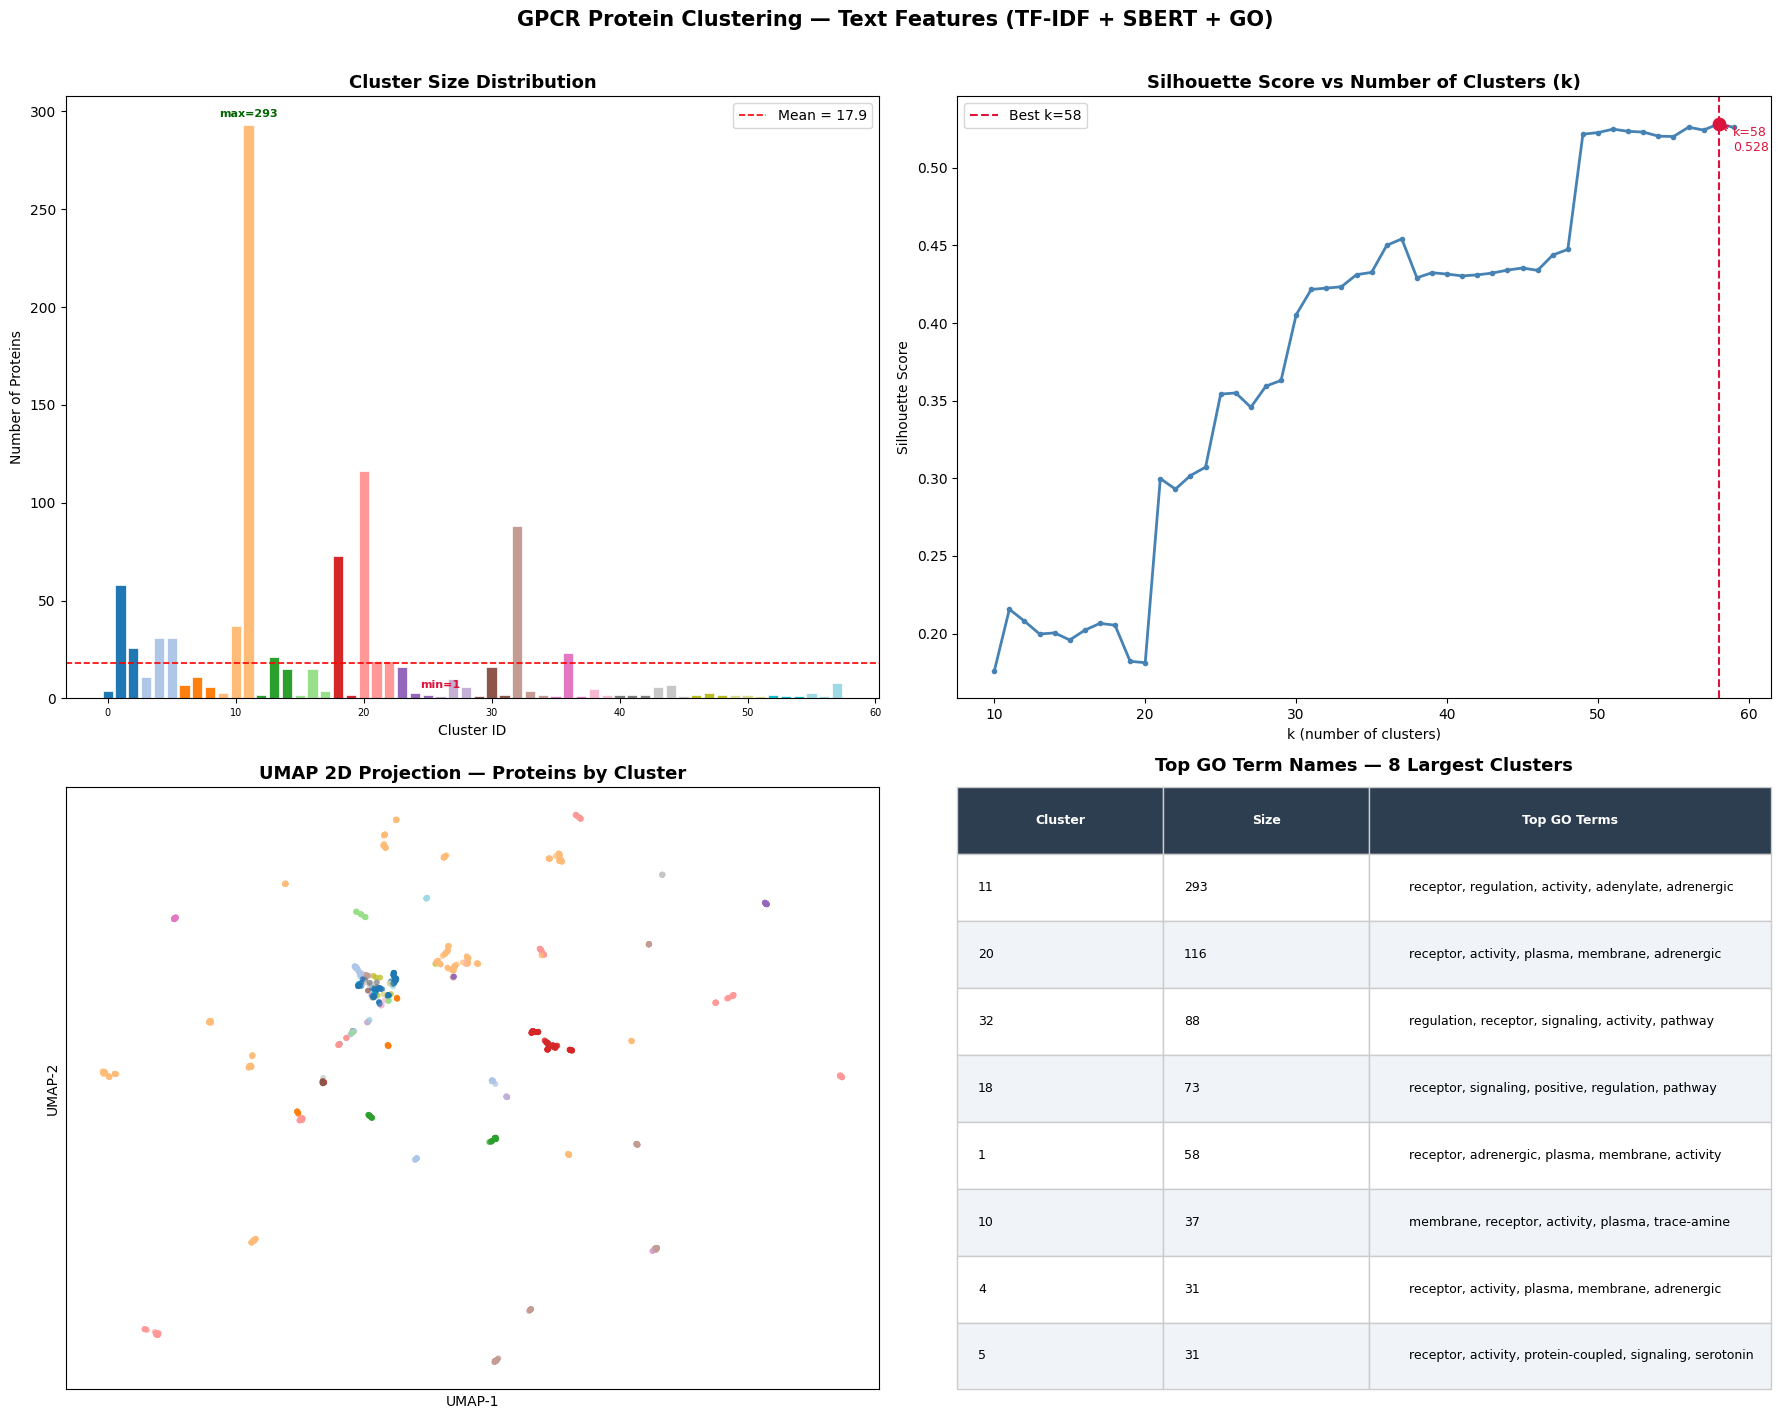

Plot saved → ../results/figures/cluster_visualization.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from collections import Counter

# Try to import UMAP — install if missing
try:
    from umap import UMAP
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
    from umap import UMAP

# ─── Color palette ────────────────────────────────────────────────────────────
n_clusters = df['hybrid_cluster'].nunique()
cmap       = cm.get_cmap('tab20', n_clusters)
colors     = [cmap(i) for i in range(n_clusters)]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('GPCR Protein Clustering — Text Features (TF-IDF + SBERT + GO)',
             fontsize=15, fontweight='bold', y=1.01)

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Cluster size distribution
# ═══════════════════════════════════════════════════════════════════════════════
ax1 = axes[0, 0]
cluster_sizes = df['hybrid_cluster'].value_counts().sort_index()
bar_colors    = [colors[i % len(colors)] for i in cluster_sizes.index]

ax1.bar(cluster_sizes.index, cluster_sizes.values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster ID')
ax1.set_ylabel('Number of Proteins')
ax1.axhline(cluster_sizes.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean = {cluster_sizes.mean():.1f}')
ax1.legend()
ax1.tick_params(axis='x', labelsize=7)

ax1.annotate(f'max={cluster_sizes.max()}',
             xy=(cluster_sizes.idxmax(), cluster_sizes.max()),
             xytext=(0, 6), textcoords='offset points',
             ha='center', fontsize=8, color='darkgreen', fontweight='bold')
ax1.annotate(f'min={cluster_sizes.min()}',
             xy=(cluster_sizes.idxmin(), cluster_sizes.min()),
             xytext=(0, 6), textcoords='offset points',
             ha='center', fontsize=8, color='crimson', fontweight='bold')

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Silhouette score vs k
# ═══════════════════════════════════════════════════════════════════════════════
ax2 = axes[0, 1]
k_vals = list(k_range)
ax2.plot(k_vals, scores, color='steelblue', linewidth=2, marker='o', markersize=3)
ax2.axvline(best_k, color='crimson', linestyle='--', linewidth=1.5, label=f'Best k={best_k}')
ax2.scatter([best_k], [best_score], color='crimson', zorder=5, s=80)
ax2.set_title('Silhouette Score vs Number of Clusters (k)', fontsize=13, fontweight='bold')
ax2.set_xlabel('k (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.annotate(f'k={best_k}\n{best_score:.3f}',
             xy=(best_k, best_score),
             xytext=(10, -20), textcoords='offset points',
             fontsize=9, color='crimson',
             arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — UMAP 2D projection
# ═══════════════════════════════════════════════════════════════════════════════
ax3 = axes[1, 0]
print("Computing UMAP projection (this may take ~30s)...")

reducer   = UMAP(n_components=2, metric='precomputed', random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(hybrid_dist)

scatter_colors = [colors[c % len(colors)] for c in df['hybrid_cluster']]
ax3.scatter(embedding[:, 0], embedding[:, 1],
            c=scatter_colors, s=18, alpha=0.75, linewidths=0)

# Cluster centroid labels
# for cid in sorted(df['hybrid_cluster'].unique()):
#     mask = df['hybrid_cluster'] == cid
#     cx, cy = embedding[mask, 0].mean(), embedding[mask, 1].mean()
#     ax3.text(cx, cy, str(cid), fontsize=6.5, ha='center', va='center',
#              fontweight='bold', color='black',
#              bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.5, linewidth=0))

ax3.set_title('UMAP 2D Projection — Proteins by Cluster', fontsize=13, fontweight='bold')
ax3.set_xlabel('UMAP-1')
ax3.set_ylabel('UMAP-2')
ax3.set_xticks([])
ax3.set_yticks([])

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Top GO term names per cluster (top 8 clusters by size)
# ═══════════════════════════════════════════════════════════════════════════════
ax4 = axes[1, 1]
ax4.axis('off')

top_clusters = cluster_sizes.nlargest(8).index.tolist()
table_data   = []
col_labels   = ['Cluster', 'Size', 'Top GO Terms']

for cid in top_clusters:
    subset = df[df['hybrid_cluster'] == cid]
    all_go = " ".join(subset['GO_name_text'].fillna('').tolist())
    words  = [w for w in all_go.lower().split() if len(w) > 4]
    top_5  = [w for w, _ in Counter(words).most_common(5)]
    table_data.append([str(cid), str(len(subset)), ', '.join(top_5)])

tbl = ax4.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='left',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    else:
        cell.set_facecolor('white')
    if col == 2:
        cell.set_width(0.65)

ax4.set_title('Top GO Term Names — 8 Largest Clusters', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('../results/figures/cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → ../results/figures/cluster_visualization.png")

In [ ]:
print("Saving text embeddings and distance matrices...")

os.makedirs('../data/processed', exist_ok=True)

np.save('../data/processed/text_distance.npy', hybrid_dist)

np.save('../data/processed/embeddings_sbert.npy', sbert_embeddings)

scipy.sparse.save_npz('../data/processed/embeddings_tfidF.npz', tfidf_embeddings)

print("\nSuccess! All distances and embeddings are safely saved to the hard drive.")

Saving text embeddings and distance matrices...

Success! All distances and embeddings are safely saved to the hard drive.
